<a href="https://colab.research.google.com/github/arpit241001001150-gif/machine_learning/blob/main/Assignment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Data Preparation and Linear Regression

First, we'll create a synthetic dataset, then split it into features (Level) and labels (Salary), and finally train a simple Linear Regression model.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Create a synthetic dataset resembling Position_Salaries
# Levels are typically 1-10, with salaries increasing non-linearly.
levels = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
salaries = np.array([45000, 50000, 60000, 80000, 110000, 150000, 200000, 300000, 500000, 1000000])

df = pd.DataFrame({'Level': levels, 'Salary': salaries})
display(df)

# Split the dataset into features (X = Level) and labels (y = Salary)
X = df[['Level']].values # Features must be a 2D array
y = df['Salary'].values   # Labels can be a 1D array

# Train a Linear Regression model on the whole dataset
linear_regressor = LinearRegression()
linear_regressor.fit(X, y)

print("\nLinear Regression Model Trained.")

,Level,Salary
0,1,45000
1,2,50000
2,3,60000
3,4,80000
4,5,110000
5,6,150000
6,7,200000
7,8,300000
8,9,500000
9,10,1000000



Linear Regression Model Trained.


## Task 2: Polynomial Regression Model (Degree 4)

Now, we'll train a Polynomial Regression model of degree 4 using `PolynomialFeatures` and `LinearRegression`.

In [4]:
# Train a Polynomial Regression model of degree 4
poly_features = PolynomialFeatures(degree=4)
X_poly = poly_features.fit_transform(X)

poly_regressor = LinearRegression()
poly_regressor.fit(X_poly, y)

print("Polynomial Regression Model (Degree 4) Trained.")

Polynomial Regression Model (Degree 4) Trained.


## Task 3 & 4: Visualize Linear and Polynomial Regression Results

We'll plot the actual data points against both the Linear Regression line and the Polynomial Regression curve.

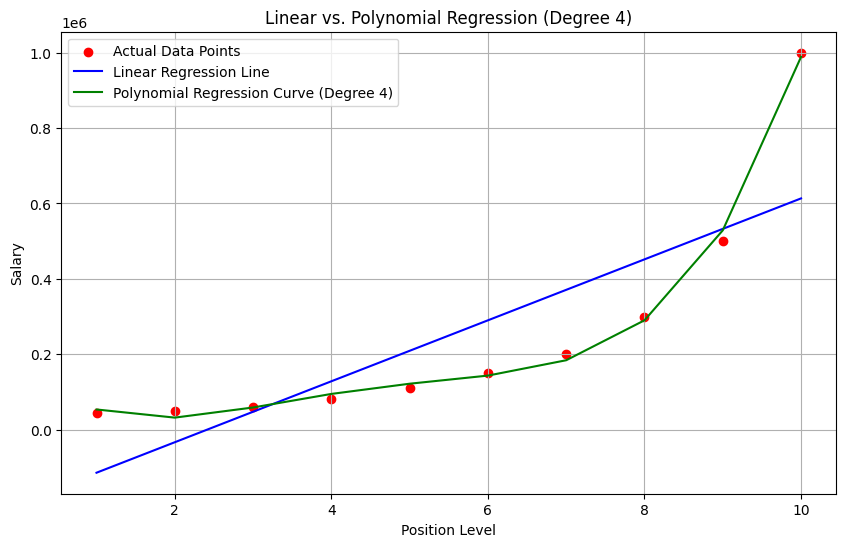

In [5]:
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(X, y, color='red', label='Actual Data Points')

# Plot Linear Regression results
plt.plot(X, linear_regressor.predict(X), color='blue', label='Linear Regression Line')

# Plot Polynomial Regression results
# We need to transform X to polynomial features before predicting with the poly_regressor
plt.plot(X, poly_regressor.predict(poly_features.fit_transform(X)), color='green', label='Polynomial Regression Curve (Degree 4)')

plt.title('Linear vs. Polynomial Regression (Degree 4)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

## Task 5: Improve Polynomial Regression Plot's Resolution and Smoothness

To make the polynomial curve smoother, we'll create a finer grid of X values for prediction and plotting.

/tmp/ipykernel_3963/536162461.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1) # Step size 0.1 for smoothness


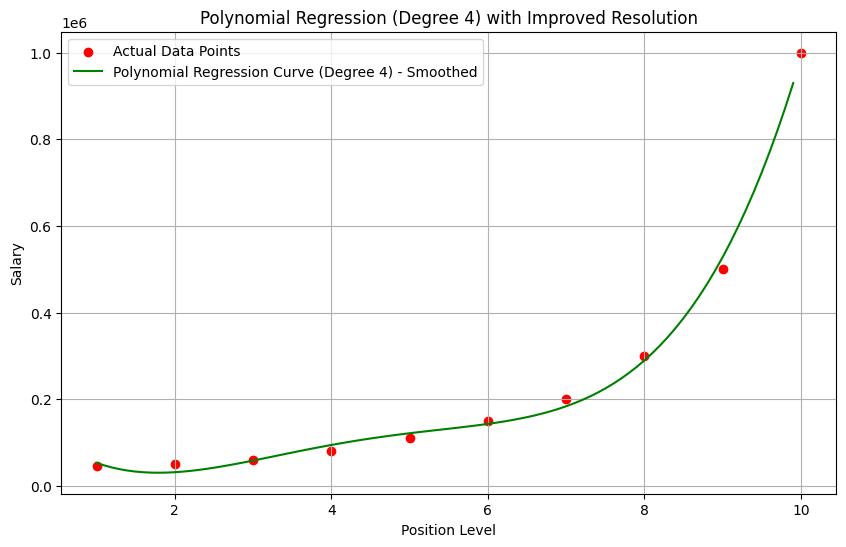

In [6]:
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(X, y, color='red', label='Actual Data Points')

# Create a finer grid for X values
X_grid = np.arange(min(X), max(X), 0.1).reshape(-1, 1) # Step size 0.1 for smoothness

# Plot Polynomial Regression results with improved resolution
plt.plot(X_grid, poly_regressor.predict(poly_features.fit_transform(X_grid)),
         color='green', label='Polynomial Regression Curve (Degree 4) - Smoothed')

plt.title('Polynomial Regression (Degree 4) with Improved Resolution')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

## Task 6: Predict Salary for Position Level 6.5

We'll use both the Linear and Polynomial Regression models to predict the salary for a new, unseen position level of 6.5.

In [7]:
level_to_predict = np.array([[6.5]]) # Must be 2D array

# Predict using Linear Regression model
linear_prediction = linear_regressor.predict(level_to_predict)
print(f"Prediction with Linear Regression for Level 6.5: ${linear_prediction[0]:,.2f}")

# Predict using Polynomial Regression model
# First, transform the input level to polynomial features
poly_level_to_predict = poly_features.fit_transform(level_to_predict)
poly_prediction = poly_regressor.predict(poly_level_to_predict)
print(f"Prediction with Polynomial Regression for Level 6.5: ${poly_prediction[0]:,.2f}")

Prediction with Linear Regression for Level 6.5: $330,378.79
Prediction with Polynomial Regression for Level 6.5: $158,862.45


## Task 7: Compare Predictions and Conclude

Finally, we'll compare the predictions from both models and determine which one is more realistic for this type of problem.

In [8]:
print(f"Linear Regression Prediction for Level 6.5: ${linear_prediction[0]:,.2f}")
print(f"Polynomial Regression Prediction for Level 6.5: ${poly_prediction[0]:,.2f}")

print("\nConclusion:")
print("For the 'Truth or Bluff' salary problem (where salaries increase non-linearly with position level),")
print("the Polynomial Regression model generally provides a more realistic and accurate prediction.")
print("Linear Regression struggles to capture the non-linear patterns, often underestimating at higher levels.")
print("The polynomial model, by fitting a curve to the data, better reflects the complex relationship between Position Level and Salary.")

Linear Regression Prediction for Level 6.5: $330,378.79
Polynomial Regression Prediction for Level 6.5: $158,862.45

Conclusion:
For the 'Truth or Bluff' salary problem (where salaries increase non-linearly with position level),
the Polynomial Regression model generally provides a more realistic and accurate prediction.
Linear Regression struggles to capture the non-linear patterns, often underestimating at higher levels.
The polynomial model, by fitting a curve to the data, better reflects the complex relationship between Position Level and Salary.
